тут я сравниваю разные модели

In [ ]:
import pandas as pd

from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

In [4]:
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/val.csv")

X_train = train_df["full_text"]
y_train = train_df["target"]

X_val = val_df["full_text"]
y_val = val_df["target"]

In [5]:
tfidf = TfidfVectorizer(
    max_features=30000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_vec = tfidf.fit_transform(X_train)
X_val_vec = tfidf.transform(X_val)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "MultinomialNB": MultinomialNB(),
    "LinearSVC": LinearSVC(random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )
}

In [6]:
results = []

for name, model in models.items():
    print("Training:", name)

    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_val_vec)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    results.append({
        "model": name,
        "accuracy": acc,
        "f1_score": f1
    })

Training: LogisticRegression
Training: MultinomialNB
Training: LinearSVC
Training: RandomForest
Training: XGBoost


                model  accuracy  f1_score
4             XGBoost  0.997739  0.997833
3        RandomForest  0.996835  0.996960
2           LinearSVC  0.996609  0.996751
0  LogisticRegression  0.991861  0.992194
1       MultinomialNB  0.955912  0.957820


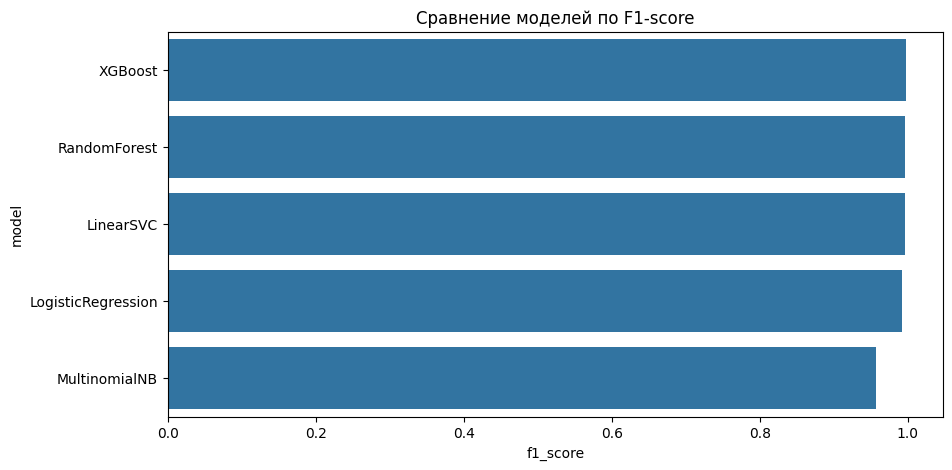

In [9]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("f1_score", ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="f1_score", y="model")

plt.title("Сравнение моделей по F1-score")
print(results_df[["model", "accuracy", "f1_score"]])
plt.show()